#Question - 1 : Netflix Data Visualization Project
Dataset link : https://www.kaggle.com/datasets/shivamb/netflix-shows

##Task to perform
—----------------------
- Which type of content is more available on Netflix?
- Which countries contribute the most content to Netflix?
- Which directors have the most titles on Netflix?



In [ ]:
#Step 1 : Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Step 2 : Load Dataset

data = pd.read_csv("netflix_titles.csv.zip")

In [ ]:
#Step 3 : Basic Dataset Information

print("First 5 Rows")
print(data.head())

print("\nDataset Information")
print(data.info())

print("\nStatistical Summary")
print(data.describe())

print("\nMissing Values")
print(data.isnull().sum())

First 5 Rows
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24,

In [ ]:
data.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


##Question 1
Which type of content is more available on Netflix?


type
Movie      6131
TV Show    2676
Name: count, dtype: int64


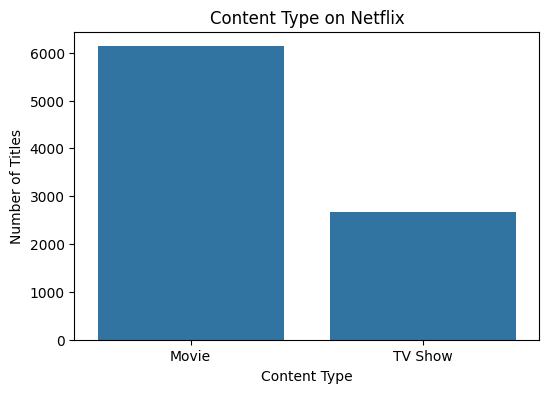


Conclusion:
Movie is more available on Netflix.


In [ ]:
content_count = data["type"].value_counts()

print(content_count)

plt.figure(figsize=(6,4))

sns.countplot(x="type", data=data)

plt.title("Content Type on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

print("\nConclusion:")
print(content_count.idxmax(),"is more available on Netflix.")

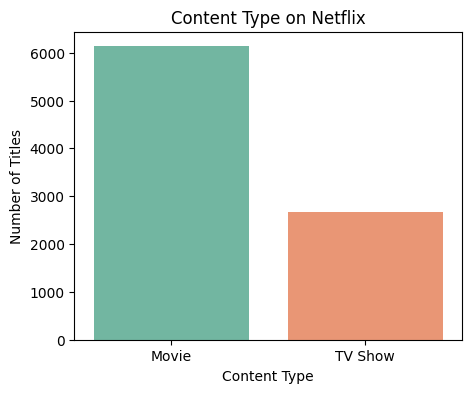

In [ ]:
#Using Seaborn

plt.figure(figsize=(5,4))

sns.countplot(data=data,
              x="type",
              hue="type",
              palette="Set2",
              legend=False)

plt.title("Content Type on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

##Question 2
Which countries contribute the most content to Netflix?

In [ ]:
# Remove missing values only from the country column
country = data["country"].dropna()

In [ ]:
# Create an empty dictionary
country_count = {}

# Count each country separately
for countries in country:

    # Split multiple countries
    for country_name in countries.split(","):

        # Remove extra spaces
        country_name = country_name.strip()

        # Count occurrences
        if country_name in country_count:
            country_count[country_name] += 1
        else:
            country_count[country_name] = 1

In [ ]:
# Convert dictionary into Pandas Series
country_count = pd.Series(country_count)

# Sort in descending order
country_count = country_count.sort_values(ascending=False)

# Display top 10 countries
print(country_count.head(10))

United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
dtype: int64


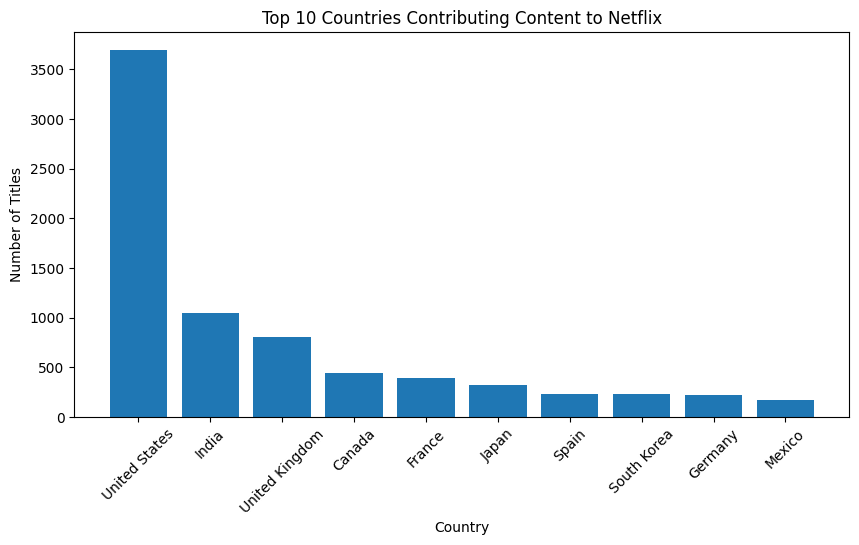

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(country_count.head(10).index,
        country_count.head(10).values)

plt.title("Top 10 Countries Contributing Content to Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

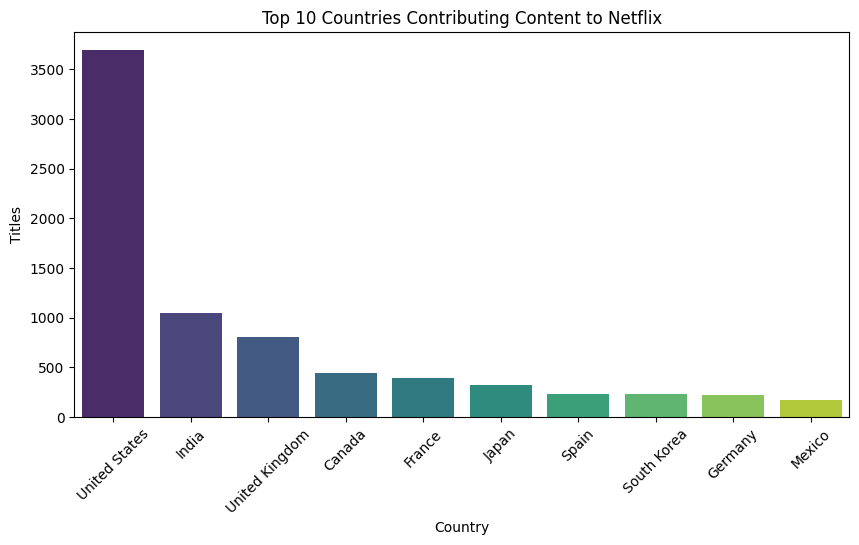

In [ ]:
#Using Seaborn

top_country = country_count.head(10).reset_index()

top_country.columns = ["Country","Titles"]

plt.figure(figsize=(10,5))

sns.barplot(data=top_country,
            x="Country",
            y="Titles",
            hue="Country",
            palette="viridis",
            legend=False)

plt.title("Top 10 Countries Contributing Content to Netflix")

plt.xticks(rotation=45)

plt.show()

#Question 3:
Which directors have the most titles on Netflix?

In [ ]:
# Remove missing values only from the director column
director = data["director"].dropna()

In [ ]:
# Count number of titles for each director
director_count = director.value_counts()

# Display top 10 directors
print(director_count.head(10))

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


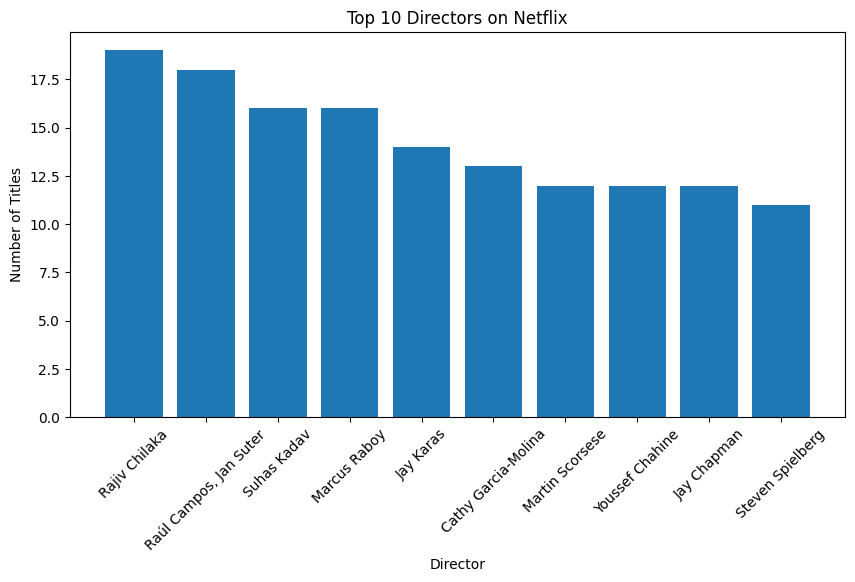

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(director_count.head(10).index,
        director_count.head(10).values)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

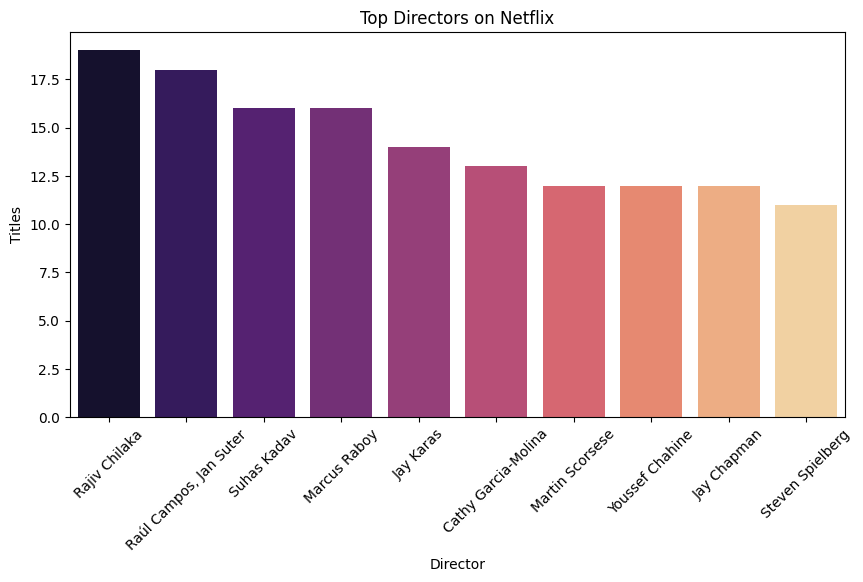

In [ ]:
#Using Seaborn

top_director = director_count.head(10).reset_index()

top_director.columns=["Director","Titles"]

plt.figure(figsize=(10,5))

sns.barplot(data=top_director,
            x="Director",
            y="Titles",
            hue="Director",
            palette="magma",
            legend=False)

plt.title("Top Directors on Netflix")

plt.xticks(rotation=45)

plt.show()